# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [1]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_genes = pd.read_csv("df_gene_info.csv", index_col='Unnamed: 0')
print(df_genes)

       len inicio_nome  count_a  hu_in_name
oxa23    5          ox        1       False
kpc      3          kp        0       False
vim      3          vi        0       False
ndm      3          nd        0       False
tet      3          te        0       False


In [3]:
df_genes['id_protein'] = [
    "WP_001046004.1",
    "WP_063860633.1",
    "WP_013263789.1",
    "WP_004201164.1",
    "WP_063856115.1",
]

df_genes['id_entrez'] = [
    "NG_049525.1",
    "NG_049243.1",
    "NG_050336.1",
    "NG_049326.1",
    "NG_048222.1",
]

df_genes

,len,inicio_nome,count_a,hu_in_name,id_protein,id_entrez
oxa23,5,ox,1,False,WP_001046004.1,NG_049525.1
kpc,3,kp,0,False,WP_063860633.1,NG_049243.1
vim,3,vi,0,False,WP_013263789.1,NG_050336.1
ndm,3,nd,0,False,WP_004201164.1,NG_049326.1
tet,3,te,0,False,WP_063856115.1,NG_048222.1


In [5]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "lusarodrigo4@email.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./arquivos_fasta/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [ ]:
'''
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)
    print(nome_gene, id_gene)
'''
# Deixei em comentário pra não rodar de novo sem querer

oxa23 WP_001046004.1
kpc WP_063860633.1
vim WP_013263789.1
ndm WP_004201164.1
tet WP_063856115.1


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [19]:
genes_seq = {
    df_genes.index[0]: 'MNKYFTCYVVASLFLSGCTVQHNLINETPSQIVQGHNQVIHQYFDEKNTSGVLVIQTDKKINLYGNALSRANTEYVPASTFKMLNALIGLENQKTDINEIFKWKGEKRSFTAWEKDMTLGEAMKLSAVPVYQELARRIGLDLMQKEVKRIGFGNAEIGQQVDNFWLVGPLKVTPIQEVEFVSQLAHTQLPFSEKVQANVKNMLLLEESNGYKIFGKTGWAMDIKPQVGWLTGWVEQPDGKIVAFALNMEMRSEMPASIRNELLMKSLKQLNII',
    df_genes.index[1]: 'MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGVYAMDTGSGATVSYRAEERFPLCSSFKGFLAAAVLARSQQQAGLLDTPIRYGKNALVRWSPISEKYLTTGMTVAELSAAAVQYSDNAAANLLLKELGGPAGLTAFMRSIGDTTFRLDRWELELNSAIPGDARDTSSPRAVTESLQKLTLGSALAAPQRQQFVDWKGNTTGNHRIRAAVPADWAVGDKTGTCGVYGTANDYAVVWPTGRAPIVLAVYTRAPNKDDKYSEAVIAAAARLALEGLGVNGQ',
    df_genes.index[2]: 'MLKVISSLLVYMTASVMAVASPLAHSGEPSGEYPTVNEIPVGEVRLYQIADGVWSHIATQSFDGAVYPSNGLIVRDGDELLLIDTAWGAKNTAALLAEIEKQIGLPVTRAVSTHFHDDRVGGVDVLRAAGVATYASPSTRRLAEAEGNEIPTHSLEGLSSSGDAVRFGPVELFYPGAAHSTDNLVVYVPSANVLYGGCAVHELSSTSAGNVADADLAEWPTSVERIQKHYPEAEVVIPGHGLPGGLDLLQHTANVVKAHKNRSVAE',
    df_genes.index[3]: 'MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRFGDLVFRQLAPNVWQHTSYLDMPGFGAVASNGLIVRDGGRVLVVDTAWTDDQTAQILNWIKQEINLPVALAVVTHAHQDKMGGMDALHAAGIATYANALSNQLAPQEGMVAAQHSLTFAANGWVEPATAPNFGPLKVFYPGPGHTSDNITVGIDGTDIAFGGCLIKDSKAKSLGNLGDADTEHYAASARAFGAAFPKASMIVMSHSAPDSRAAITHTARMADKLR',
    df_genes.index[4]: 'MKIINIGVLAHVDAGKTTLTESLLYNSGAITELGSVDKGTTRTDNTLLERQRGITIQTGITSFQWENTKVNIIDTPGHMDFLAEVYRSLSVLDGAILLISAKDGVQAQTRILFHALRKMGIPTIFFINKIDQNGIDLSTVYQDIKEKLSAEIVIKQKVELYPNMCVTNFTESEQWDTVIEGNDDLLEKYTSGKLLEALELEQEESIRFHNCSLFPVYHGSAKNNIGIDNLIEVITNKFYSSTHRGQSELCGKVFKIEYTKKRQRLAYIRLYSGVLHLRDSVRVSEKEKIKVTEMYTSINGELCKIDRAYSGEIVILQNEFLKLNSVLGDTKLLPQRKKIENPHPLLQTTVEPSKPEQREMLLDALLEISDSDPLLRYYVDSTTHEIILSFLGKVQMEVISALLQEKYHVEIELKEPTVIYMERPLKNAEYTIHIEVPPNPFWASIGLSVSPLPLGSGMQYESSVSLGYLNQSFQNAVMEGIRYGCEQGLYGWNVTDCKICFKYGLYYSPVSTPADFRMLAPIVLEQVLKKAGTELLEPYLSFKIYAPQEYLSRAYNDAPKYCANIVDTQLKNNEVILSGEIPARCIQEYRSDLTFFTNGRSVCLTELKGYHVTTGEPVCQPRRPNSRIDKVRYMFNKIT',
}

In [20]:
genes_seq_df = pd.DataFrame.from_dict(
    genes_seq,
    orient='index',
    columns=['seq']
)

genes_seq_df

,seq
oxa23,MNKYFTCYVVASLFLSGCTVQHNLINETPSQIVQGHNQVIHQYFDE...
kpc,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...
vim,MLKVISSLLVYMTASVMAVASPLAHSGEPSGEYPTVNEIPVGEVRL...
ndm,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...
tet,MKIINIGVLAHVDAGKTTLTESLLYNSGAITELGSVDKGTTRTDNT...


In [26]:
# Gerar outro df com as frequencias absolutas dos aminoacidos pra cada gene. 
from collections import Counter

freq_dict = {}

for gene, seq in genes_seq.items():
    freq_dict[gene] = Counter(seq)

df_freq = pd.DataFrame.from_dict(freq_dict, orient='index').fillna(0).astype(int)
df_freq

,M,N,K,Y,F,T,C,V,A,S,L,G,Q,H,I,E,P,D,R,W
oxa23,11,19,22,7,12,14,2,21,16,14,27,18,18,4,18,20,9,8,7,6
kpc,4,10,10,10,9,21,3,19,44,21,33,26,10,1,8,12,13,14,18,6
vim,3,9,6,9,4,14,1,30,32,23,25,24,5,11,11,18,15,13,10,3
ndm,12,11,9,4,9,17,2,16,41,14,22,25,12,10,14,7,15,17,9,4
tet,12,31,42,32,20,42,11,41,26,45,70,37,27,12,53,52,27,27,28,4


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [29]:
df_freq['V']

oxa23    21
kpc      19
vim      30
ndm      16
tet      41
Name: V, dtype: int64

In [33]:
df_freq['V'].idxmax()

'tet'

## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [46]:
print("Média = ", df_freq['S'].mean())
print("Mediana = ", df_freq['S'].median())
print("Moda = ", df_freq['S'].mode())

df_freq['S'].describe()

Média =  23.4
Mediana =  21.0
Moda =  0    14
Name: S, dtype: int64


count     5.000000
mean     23.400000
std      12.739702
min      14.000000
25%      14.000000
50%      21.000000
75%      23.000000
max      45.000000
Name: S, dtype: float64

## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

oxa23    14
kpc      21
vim      23
ndm      14
tet      45
Name: S, dtype: int64


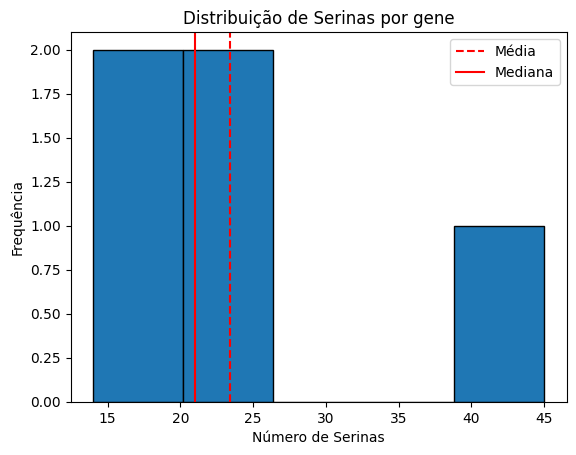

In [85]:
serie_serinas = df_freq['S']
print(serie_serinas)


plt.hist(serie_serinas, bins=5, edgecolor='black')
plt.axvline(serie_serinas.mean(), linestyle='--', label='Média', color='red')
plt.axvline(serie_serinas.median(), linestyle='-', label='Mediana', color='red')
plt.title('Distribuição de Serinas por gene')
plt.xlabel('Número de Serinas')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [97]:
def plot_hist(dataframe: pd.DataFrame, aa: str):
    
    # Deixa upper case
    aa = aa.upper()

    # Se não estiver na lista, não é aminoácido
    if aa not in ["M", "N", "K", "Y", "F", "T",	"C", "V", "A", "S",	"L", "G", "Q", "H", "I", "E", "P", "D", "R", "W"]:
        print("A letra fornecida não corresponde a um aminoácido!")    
    
    # Instancia uma série contendo os valores de count para cada gene no aa correspondente
    serie = dataframe[aa]

    # Plota o gráfico
    plt.hist(serie, bins=5, edgecolor='black')
    plt.axvline(serie.mean(), linestyle='--', label='Média', color='red')
    plt.axvline(serie.median(), linestyle='-', label='Mediana', color='red')
    plt.title(f"Distribuição do número de aminoácidos '{aa}' por gene")
    plt.xlabel('Número de aminoácidos')
    plt.ylabel('Frequência')
    plt.legend()
    plt.show()

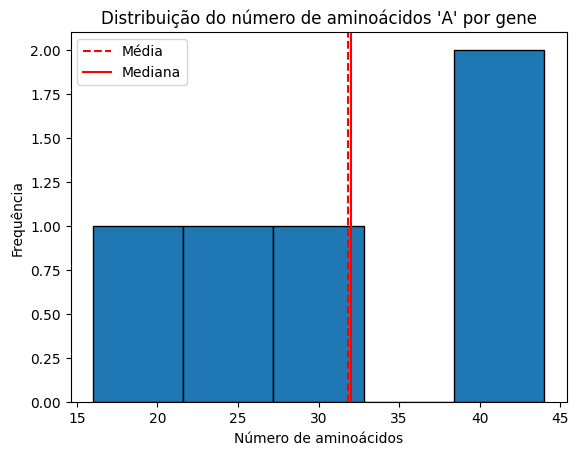

In [98]:
plot_hist(df_freq, 'a')

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

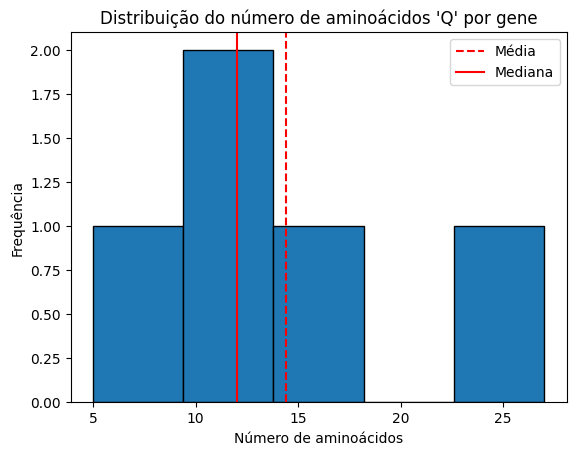

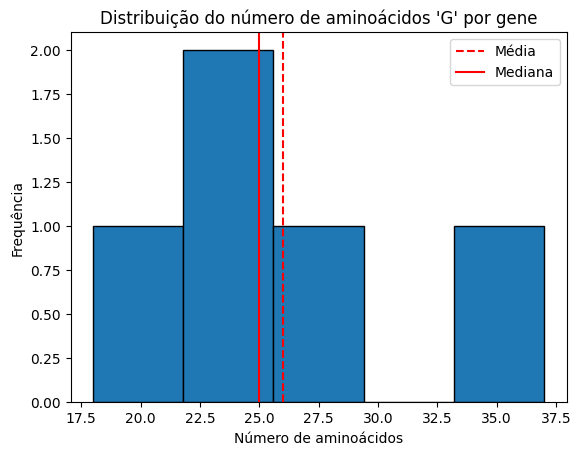

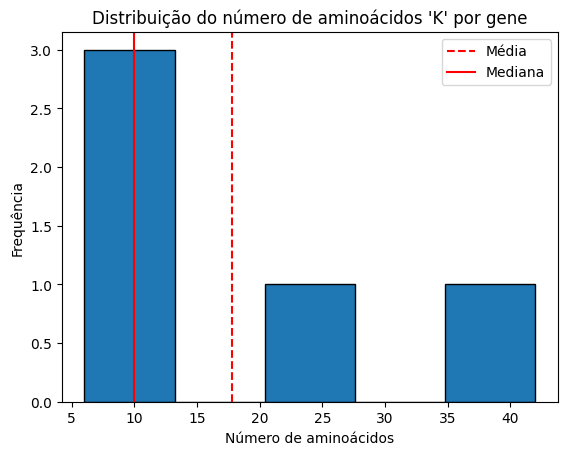

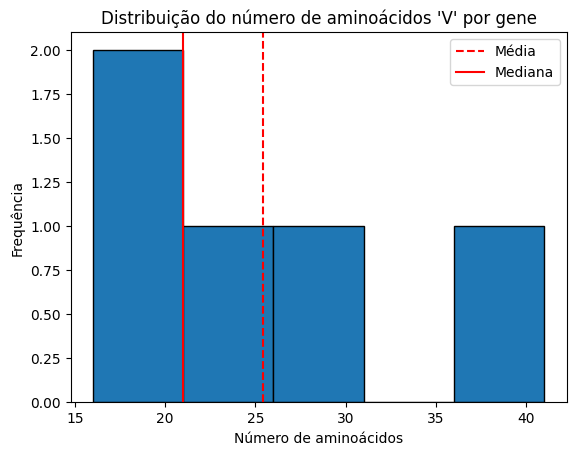

In [99]:
plot_hist(df_freq, 'Q')
plot_hist(df_freq, 'G')
plot_hist(df_freq, 'K')
plot_hist(df_freq, 'V')

*R:* O aminoácido de símbolo G é aquele que apresenta a menor diferença entre a média e mediana.

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [106]:
#plot_hist(df_freq, 'Q')

print(f"A média de cisteínas nos tres primeiros genes é {df_freq.iloc[0:3]['C'].mean()}")
print(f"A mediana de cisteínas nos tres primeiros genes é {df_freq.iloc[0:3]['C'].median()}")

A média de cisteínas nos tres primeiros genes é 2.0
A mediana de cisteínas nos tres primeiros genes é 2.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [128]:
# Não existe numero médio de aa por gene, apenas o numero de aa total em cada gene
for i in range(len(genes_seq_df)):
    print(f"{genes_seq_df.index[i]}: {len(genes_seq_df.iloc[i]["seq"])} aminoácidos")

oxa23: 273 aminoácidos
kpc: 292 aminoácidos
vim: 266 aminoácidos
ndm: 270 aminoácidos
tet: 639 aminoácidos


O maior gene é o 'tet', que possui, 639 aminoácidos.

## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

O menor gene é 'vim', com 266 aminoácidos.